<a href="https://colab.research.google.com/github/DRAGOSYS/Decision-Tree-Classifier/blob/main/MnistDataClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.8699 - loss: 0.4244 - val_accuracy: 0.9807 - val_loss: 0.0661
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9824 - loss: 0.0577 - val_accuracy: 0.9829 - val_loss: 0.0524
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9878 - loss: 0.0383 - val_accuracy: 0.9882 - val_loss: 0.0337
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9895 - val_loss: 0.0301
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9929 - loss: 0.0220 - val_accuracy: 0.9886 - val_loss: 0.0385
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9858 - loss: 0.0465
test accuracy:98.86%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
prediction for first test image:7


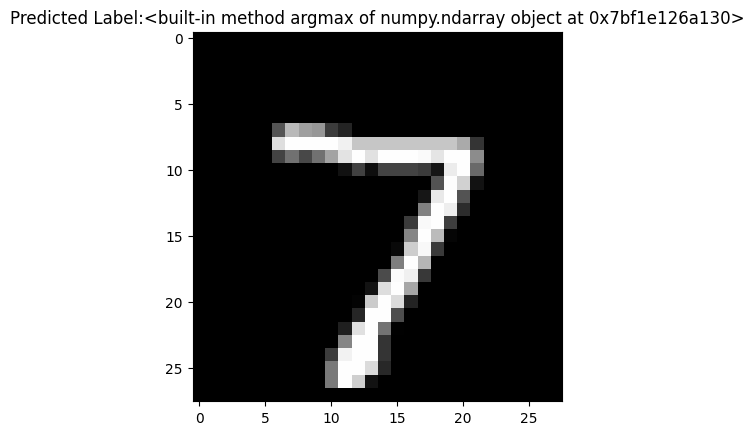

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
from tensorflow.keras.utils import to_categorical
(train_images,train_labels),(test_images,test_labels)=datasets.mnist.load_data()
train_images=train_images/255.0
test_images=test_images/255.0
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))
train_labels=to_categorical((train_labels))
test_labels=to_categorical((test_labels))
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.Flatten())#flatten the 3D output to 1D
model.add(layers.Flatten())#flatten the 3D output to 1D
model.add(layers.Dense(64,activation='relu'))#Add a dense layer
model.add(layers.Dense(10,activation='softmax'))#output layers with 10 neuronsfor 10 digit classes
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
#train the model
model.fit(train_images,train_labels,epochs=5,batch_size=64,validation_data=(test_images,test_labels))
#evaluate the model on test data
test_loss,test_acc=model.evaluate(test_images,test_labels)
print(f"test accuracy:{test_acc*100:.2f}%")
#make predictions on test_iamges
predictions=model.predict(test_images)
print(f"prediction for first test image:{np.argmax(predictions[0])}")
plt.imshow(test_images[0].reshape(28,28),cmap='grey')
plt.title(f"Predicted Label:{predictions[1].argmax}")
plt.show()